EXECUTE FIRST LINE OF CODE QQ_merge_stationxml.py

In [2]:
# %% [markdown]
# # Clasificación de sismicidad volcánica mediante Frequency Index (FI)
# Basado en Song & Tan (2025), JGR Solid Earth

# %% [markdown]
# ## 1. Importaciones y configuración

# %%
import json
from pathlib import Path
from functools import lru_cache
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, read_inventory, UTCDateTime
from obspy.geodetics import gps2dist_azimuth
from obspy.signal.util import next_pow_2

from scipy.signal import find_peaks, hilbert
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
VOLCANO = {
    "name": "pavlof_2021",
    "lat": 55.4173,
    "lon": -161.8937,
}

BASE_DIR = Path("/home/elizabeth/soft/src/QuickQuake")
DATA_DIR = BASE_DIR / "data"
MERGED_DIR = DATA_DIR / "merged"

PATHS = {
    "data_base": DATA_DIR,
    "catalog_csv": MERGED_DIR / "output" / "GAMMA_hypodd_catalog_qcfiltered.csv",
    "picks_csv": MERGED_DIR / "input/GAMMA_picks_cleaned.csv",
    "stations_json": MERGED_DIR / "input" / "GAMMA_station_list.json",
    "inventory_xml": MERGED_DIR / "input" / "stations_merged.xml",
    "output_csv": MERGED_DIR / "output" / "GAMMA_hypodd_catalog_qcfiltered_FI.csv",
    "output_dir": MERGED_DIR / "output" / "fi_outputs",
}

PATHS["output_dir"].mkdir(parents=True, exist_ok=True)

FILTERS = {
    "event_radius_km": 100.0,
    "station_max_dist_km": 67.0,
    "min_stations": 2,
    "snr_threshold": 2.0,
}

WINDOWS = {
    # ventana final usada para FI
    "p_rel_start_s": -1.0,
    "p_win_len_s": 7.0,
    "noise_win_s": 5.0,

    # ventana local alrededor del pick P para refinar el peak
    "peak_search_pre_s": 0.30,
    "peak_search_post_s": 1.50,
}

CLASSIFICATION = {
    # "auto" = usa mínimo local; si no hay separación clara, devuelve NS
    "method": "auto",

    "auto_min_events": 20,
    "kde_bw_method": 0.25,
    "peak_prominence_fraction": 0.08,
    "min_peak_separation_fraction": 0.12,

    # criterio extra para no aceptar “valles” muy débiles
    "min_valley_drop_fraction": 0.12,
}

PLOT = {
    "hist_bins": 20,
}

In [3]:
# %% [markdown]
# ## 2. Funciones auxiliares (distancias, carga de datos)

# %%
def normalize_event_id(series):
    s = series.astype(str).str.strip()
    s = s.str.replace(r"\.0+$", "", regex=True)
    s = s.str.replace(r"\s+", "", regex=True)
    return s

def horizontal_distance_km(lat1, lon1, lat2, lon2):
    dist_m, _, _ = gps2dist_azimuth(lat1, lon1, lat2, lon2)
    return dist_m / 1000.0

def get_hypocentral_distances(stations_df, ev_lat, ev_lon, ev_depth_km):
    stations_df = stations_df.copy()
    if "elev_km" not in stations_df.columns:
        stations_df["elev_km"] = 0.0

    hypo_distances = []
    for _, sta in stations_df.iterrows():
        dh_km = horizontal_distance_km(ev_lat, ev_lon, float(sta["lat"]), float(sta["lon"]))
        dz_km = ev_depth_km + float(sta["elev_km"])
        d3_km = np.sqrt(dh_km**2 + dz_km**2)
        hypo_distances.append(d3_km)

    stations_df["hypo_km"] = hypo_distances
    return dict(zip(stations_df["sta_id"], stations_df["hypo_km"]))

def filter_catalog_by_radius(df, volcano, radius_km, lat_col="latitude", lon_col="longitude"):
    out = df.copy()
    out["r_km"] = [
        horizontal_distance_km(lat, lon, volcano["lat"], volcano["lon"])
        for lat, lon in zip(out[lat_col], out[lon_col])
    ]
    out["inside_radius"] = out["r_km"] <= radius_km
    out_filtered = out[out["inside_radius"]].copy().reset_index(drop=True)
    return out, out_filtered

def infer_catalog_columns(df):
    colmap = {}
    candidates = {
        "time": ["datetime", "time", "origin_time"],
        "latitude": ["latitude", "lat"],
        "longitude": ["longitude", "lon"],
        "depth_km": ["depth_km", "depth"],
        "event_id": ["event_id", "id"],
        "magnitude": ["mag", "magnitude"],
    }

    for key, options in candidates.items():
        found = None
        for col in options:
            if col in df.columns:
                found = col
                break
        colmap[key] = found

    missing_required = [k for k in ["time", "latitude", "longitude", "event_id"] if colmap[k] is None]
    if missing_required:
        raise ValueError(
            f"Catalog is missing required columns: {missing_required}. "
            f"Available columns: {list(df.columns)}"
        )
    return colmap

def load_catalog(catalog_csv):
    catalog = pd.read_csv(catalog_csv)
    colmap = infer_catalog_columns(catalog)

    catalog[colmap["time"]] = pd.to_datetime(
        catalog[colmap["time"]], utc=True, errors="coerce"
    )
    catalog = catalog.dropna(subset=[colmap["time"]]).reset_index(drop=True)
    catalog[colmap["event_id"]] = normalize_event_id(catalog[colmap["event_id"]])

    return catalog, colmap

def load_picks(picks_csv):
    picks = pd.read_csv(picks_csv)

    if "timestamp" not in picks.columns:
        raise ValueError("The picks file must contain a 'timestamp' column.")
    picks["timestamp"] = pd.to_datetime(picks["timestamp"], utc=True, errors="coerce")
    picks = picks.dropna(subset=["timestamp"]).reset_index(drop=True)

    if "id" not in picks.columns:
        raise ValueError("The picks file must contain an 'id' column like AV.STA..BH")

    id_parts = picks["id"].astype(str).str.split(".", expand=True)
    if id_parts.shape[1] < 2:
        raise ValueError("Could not parse 'id' column to extract net and sta.")

    picks["net"] = id_parts[0]
    picks["sta"] = id_parts[1]
    picks["sta_id"] = picks["net"].astype(str) + "." + picks["sta"].astype(str)

    if "type" in picks.columns:
        picks["type"] = picks["type"].astype(str).str.upper()
    else:
        raise ValueError("The picks file must contain a 'type' column.")

    # ---- CLAVE CORRECTA DE ENLACE ----
    if "event_id_mapped" in picks.columns:
        picks["event_id_link"] = normalize_event_id(picks["event_id_mapped"])
    elif "event_id" in picks.columns:
        picks["event_id_link"] = normalize_event_id(picks["event_id"])
    else:
        raise ValueError("The picks file must contain 'event_id_mapped' or 'event_id'.")

    return picks

def load_stations(stations_json):
    with open(stations_json, "r") as f:
        stations_raw = json.load(f)

    stations_list = []
    for code, values in stations_raw.items():
        parts = code.split(".")
        net = parts[0] if len(parts) > 0 else ""
        sta = parts[1] if len(parts) > 1 else ""
        sta_id = f"{net}.{sta}" if net and sta else code

        elev_m = None
        if "elevation(m)" in values:
            elev_m = values["elevation(m)"]
        elif "elev_m" in values:
            elev_m = values["elev_m"]
        elif "elevation_m" in values:
            elev_m = values["elevation_m"]

        elev_km = float(elev_m) / 1000.0 if elev_m is not None else 0.0

        stations_list.append({
            "sta_id": sta_id,
            "net": net,
            "sta": sta,
            "lat": values.get("latitude"),
            "lon": values.get("longitude"),
            "elev_km": elev_km,
        })

    stations = pd.DataFrame(stations_list)

    required_cols = ["sta_id", "lat", "lon", "elev_km"]
    for col in required_cols:
        if col not in stations.columns:
            raise ValueError(f"Missing required station column: {col}")

    return stations

def load_inventory(inventory_xml):
    inventory_xml = Path(inventory_xml)
    if not inventory_xml.exists():
        print(f"Inventory file not found: {inventory_xml}")
        return None

    try:
        return read_inventory(str(inventory_xml))
    except Exception as e:
        print(f"Error loading inventory XML: {e}")
        return None

In [4]:
# %% [markdown]
# ## 3. Funciones de procesamiento de señal y cálculo del FI

# %%
def calculate_snr(signal_data, noise_data):
    if len(signal_data) == 0 or len(noise_data) == 0:
        return 0.0

    signal_rms = np.sqrt(np.mean(np.asarray(signal_data, dtype=float) ** 2))
    noise_rms = np.sqrt(np.mean(np.asarray(noise_data, dtype=float) ** 2))

    if noise_rms == 0:
        return np.inf
    return signal_rms / noise_rms

def preprocess_trace(trace):
    tr = trace.copy()
    tr.data = tr.data.astype(float)
    tr.detrend("demean")
    tr.detrend("linear")
    tr.taper(max_percentage=0.05, type="hann")
    return tr

def remove_instrument_response(trace, inventory):
    corrected_trace = trace.copy()
    try:
        fs = corrected_trace.stats.sampling_rate
        nyq = 0.5 * fs

        f1 = 0.5
        f2 = 1.0
        f3 = min(0.9 * nyq, nyq - 1.0)
        f4 = min(0.95 * nyq, nyq - 0.1)

        if not (f1 < f2 < f3 < f4):
            return corrected_trace, False

        corrected_trace.remove_response(
            inventory=inventory,
            output="VEL",
            water_level=60,
            pre_filt=(f1, f2, f3, f4),
        )
        return corrected_trace, True

    except Exception:
        try:
            corrected_trace = trace.copy()
            corrected_trace.remove_response(
                inventory=inventory,
                output="VEL",
                water_level=60,
            )
            return corrected_trace, True
        except Exception:
            return trace, False

def extract_signal_and_noise_windows(trace, anchor_time, windows):
    signal_start = anchor_time + windows["p_rel_start_s"]
    signal_end = signal_start + windows["p_win_len_s"]

    noise_start = signal_start - windows["noise_win_s"]
    noise_end = signal_start

    signal_trace = trace.copy()
    signal_trace.trim(signal_start, signal_end, pad=True, fill_value=0.0)

    noise_trace = trace.copy()
    noise_trace.trim(noise_start, noise_end, pad=True, fill_value=0.0)

    return signal_trace, noise_trace

def compute_amplitude_spectrum(trace):
    data = trace.data.astype(float)
    npts = len(data)

    if npts < 10:
        return None, None
    if not np.all(np.isfinite(data)):
        return None, None

    window = np.hanning(npts)
    data_windowed = data * window

    nfft = next_pow_2(npts)
    spectrum = np.fft.rfft(data_windowed, n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=trace.stats.delta)
    amp = np.abs(spectrum)

    return freqs, amp

def refine_p_peak_time(trace, p_arrival_time, windows):
    """
    Refina el pick P usando el peak local de la envolvente |analytic signal|
    dentro de una ventana corta alrededor del pick original.
    """
    tr = trace.copy()

    search_start = p_arrival_time - windows["peak_search_pre_s"]
    search_end = p_arrival_time + windows["peak_search_post_s"]

    tr.trim(search_start, search_end, pad=True, fill_value=0.0)
    if len(tr.data) < 5:
        return p_arrival_time, False

    tr = preprocess_trace(tr)

    data = tr.data.astype(float)
    if not np.all(np.isfinite(data)):
        return p_arrival_time, False

    env = np.abs(hilbert(data))
    if len(env) == 0 or np.all(env == 0):
        return p_arrival_time, False

    i_peak = int(np.argmax(env))
    refined_time = tr.stats.starttime + i_peak * tr.stats.delta

    return refined_time, True

def compute_station_fi(
    trace,
    p_arrival_time,
    windows,
    snr_threshold,
    inventory=None,
):
    """
    Calcula el Frequency Index (FI) usando:
    - peak local refinado de la onda P
    - ventana de 7 s empezando 1 s antes del peak refinado
    - bandas baja 1-5 Hz y alta 8-14 Hz
    """
    try:
        # 1) refinar la P al peak local
        refined_peak_time, peak_ok = refine_p_peak_time(trace, p_arrival_time, windows)
        anchor_time = refined_peak_time if peak_ok else p_arrival_time

        # 2) extraer ventanas respecto al peak refinado
        signal_trace, noise_trace = extract_signal_and_noise_windows(trace, anchor_time, windows)

        snr = calculate_snr(signal_trace.data.astype(float), noise_trace.data.astype(float))
        if snr < snr_threshold:
            return None

        # 3) preprocesar y remover respuesta
        processed = preprocess_trace(signal_trace)

        response_removed = False
        if inventory is not None:
            processed, response_removed = remove_instrument_response(processed, inventory)
            if not response_removed:
                return None

        if np.any(~np.isfinite(processed.data)):
            return None

        # 4) espectro
        freqs, amp = compute_amplitude_spectrum(processed)
        if freqs is None or amp is None:
            return None

        f_low_min, f_low_max = 1.0, 5.0
        f_high_min, f_high_max = 8.0, 14.0

        low_mask = (freqs >= f_low_min) & (freqs <= f_low_max)
        high_mask = (freqs >= f_high_min) & (freqs <= f_high_max)

        if not np.any(low_mask) or not np.any(high_mask):
            return None

        a_low = np.mean(amp[low_mask])
        a_high = np.mean(amp[high_mask])

        if not np.isfinite(a_low) or not np.isfinite(a_high):
            return None
        if a_low <= 0:
            return None

        fi = np.log10(a_high / a_low)

        return {
            "fi": float(fi),
            "snr": float(snr),
            "a_low": float(a_low),
            "a_high": float(a_high),
            "p_anchor_time": str(anchor_time),
            "p_refined_ok": bool(peak_ok),
            "response_removed": bool(response_removed),
            "npts": int(len(processed.data)),
        }

    except Exception:
        return None

In [5]:
# %% [markdown]
# ## 4. Funciones para chunks, picks por evento y procesamiento completo

# %%
def build_chunk_index(data_base):
    chunk_rows = []
    for p in sorted(Path(data_base).iterdir()):
        if not p.is_dir():
            continue
        if p.name == "merged":
            continue
        try:
            start = pd.to_datetime(p.name, format="%Y%m%dT%H%M%S", utc=True)
            chunk_rows.append({"folder": p.name, "start": start})
        except Exception:
            continue

    chunk_df = pd.DataFrame(chunk_rows).sort_values("start").reset_index(drop=True)
    if len(chunk_df) == 0:
        raise ValueError(f"No valid chunk folders found in {data_base}")

    chunk_df["end"] = chunk_df["start"].shift(-1)

    if len(chunk_df) > 1:
        last_duration = chunk_df.loc[len(chunk_df)-2, "end"] - chunk_df.loc[len(chunk_df)-2, "start"]
    else:
        last_duration = pd.Timedelta(hours=8)

    chunk_df.loc[len(chunk_df)-1, "end"] = chunk_df.loc[len(chunk_df)-1, "start"] + last_duration
    return chunk_df

def prepare_chunk_lookup(chunk_index):
    starts = chunk_index["start"].to_numpy(dtype="datetime64[ns]")
    ends = chunk_index["end"].to_numpy(dtype="datetime64[ns]")
    folders = chunk_index["folder"].to_numpy()
    return starts, ends, folders

def find_chunk_folder_for_event_fast(event_time, chunk_starts, chunk_ends, chunk_folders):
    t = np.datetime64(pd.Timestamp(event_time).tz_convert("UTC").tz_localize(None))
    pos = np.searchsorted(chunk_starts, t, side="right") - 1
    if pos < 0:
        return None
    if t < chunk_ends[pos]:
        return chunk_folders[pos]
    return None

@lru_cache(maxsize=32)
def read_waveform_folder_cached(data_base_str, waveform_folder_name):
    folder = Path(data_base_str) / waveform_folder_name / "waveforms"
    pattern = str(folder / "*.mseed")
    try:
        stream = read(pattern)
        return stream
    except Exception:
        return None

def build_picks_by_event_lookup(picks):
    out = {}
    picks_p = picks[picks["type"] == "P"].copy()

    for ev_id, grp in picks_p.groupby("event_id_link"):
        g = grp.copy()

        if "prob" in g.columns:
            g = (
                g.sort_values("prob", ascending=False)
                .groupby("sta_id", as_index=False)
                .first()
            )
        else:
            g = g.groupby("sta_id", as_index=False).first()

        out[str(ev_id)] = g.reset_index(drop=True)

    return out

def build_event_station_distance_lookup(catalog_filtered, stations, catalog_colmap):
    lookup = {}
    station_info = stations[["sta_id", "lat", "lon", "elev_km"]].copy()

    depth_col = catalog_colmap.get("depth_km")
    event_id_col = catalog_colmap["event_id"]

    for _, ev in catalog_filtered.iterrows():
        ev_id = str(ev[event_id_col])
        ev_lat = float(ev[catalog_colmap["latitude"]])
        ev_lon = float(ev[catalog_colmap["longitude"]])
        ev_depth = float(ev[depth_col]) if depth_col is not None else 0.0

        lookup[ev_id] = get_hypocentral_distances(
            station_info, ev_lat, ev_lon, ev_depth
        )

    return lookup

def process_event(
    event_row,
    picks_by_event,
    event_station_distance_lookup,
    data_base,
    windows,
    filters,
    inventory,
    catalog_colmap,
    chunk_starts,
    chunk_ends,
    chunk_folders,
):
    event_time = pd.Timestamp(event_row[catalog_colmap["time"]])
    event_id = str(event_row[catalog_colmap["event_id"]])
    depth_col = catalog_colmap.get("depth_km")

    result = {
        "event_id": event_id,
        "event_time": event_time,
        "event_depth_km": float(event_row[depth_col]) if depth_col is not None else np.nan,
        "r_km": event_row.get("r_km", np.nan),
        "fi": np.nan,
        "fi_std": np.nan,
        "fi_n_stations": 0,
        "fi_snr_mean": np.nan,
        "n_peaks_refined": 0,
        "status": "init",
    }

    if ("original_folder" in event_row) and pd.notna(event_row["original_folder"]):
        waveform_folder_name = str(event_row["original_folder"])
    else:
        waveform_folder_name = find_chunk_folder_for_event_fast(
            event_time, chunk_starts, chunk_ends, chunk_folders
        )

    if waveform_folder_name is None:
        result["status"] = "missing_waveform_folder"
        return result

    stream = read_waveform_folder_cached(str(data_base), waveform_folder_name)
    if stream is None:
        result["status"] = "waveform_read_error"
        return result
    if len(stream) == 0:
        result["status"] = "no_waveforms"
        return result

    event_picks = picks_by_event.get(event_id)
    if event_picks is None or event_picks.empty:
        result["status"] = "no_event_picks"
        return result

    distance_map = event_station_distance_lookup.get(event_id, {})
    event_picks = event_picks.copy()

    event_picks["hypo_km"] = event_picks["sta_id"].map(distance_map)
    event_picks = event_picks[event_picks["hypo_km"].notna()].copy()
    event_picks = event_picks[event_picks["hypo_km"] <= filters["station_max_dist_km"]].copy()

    if event_picks.empty:
        result["status"] = "no_picks_within_station_distance"
        return result

    station_fi = []
    station_snr = []
    n_peaks_refined = 0

    for _, pick in event_picks.iterrows():
        sta = str(pick["sta"])
        p_arrival = UTCDateTime(pd.Timestamp(pick["timestamp"]).to_pydatetime())

        traces = stream.select(station=sta, channel="*Z")
        if len(traces) == 0:
            continue

        traces_sorted = sorted(traces, key=lambda tr: tr.stats.sampling_rate, reverse=True)
        trace = traces_sorted[0].copy()

        fi_info = compute_station_fi(
            trace=trace,
            p_arrival_time=p_arrival,
            windows=windows,
            snr_threshold=filters["snr_threshold"],
            inventory=inventory,
        )

        if fi_info is None:
            continue

        station_fi.append(fi_info["fi"])
        station_snr.append(fi_info["snr"])
        if fi_info["p_refined_ok"]:
            n_peaks_refined += 1

    if len(station_fi) < filters["min_stations"]:
        result["status"] = "not_enough_valid_stations"
        return result

    result["fi"] = float(np.mean(station_fi))
    result["fi_std"] = float(np.std(station_fi)) if len(station_fi) > 1 else 0.0
    result["fi_n_stations"] = int(len(station_fi))
    result["fi_snr_mean"] = float(np.mean(station_snr)) if station_snr else np.nan
    result["n_peaks_refined"] = int(n_peaks_refined)
    result["status"] = "ok"

    return result

In [6]:
# %% [markdown]
# ## 5. Carga de datos y chequeo de consistencia de IDs

# %%
catalog, catalog_colmap = load_catalog(PATHS["catalog_csv"])
picks = load_picks(PATHS["picks_csv"])
stations = load_stations(PATHS["stations_json"])
inventory = load_inventory(PATHS["inventory_xml"])

print(f"Catalog events: {len(catalog)}")
print(f"Picks: {len(picks)}")
print(f"Stations: {len(stations)}")
print(f"Inventory loaded: {inventory is not None}")

catalog_full, catalog_filtered = filter_catalog_by_radius(
    catalog,
    VOLCANO,
    FILTERS["event_radius_km"],
    lat_col=catalog_colmap["latitude"],
    lon_col=catalog_colmap["longitude"],
)

print(f"Events inside {FILTERS['event_radius_km']} km: {len(catalog_filtered)} / {len(catalog)}")

catalog_ids = set(catalog_filtered[catalog_colmap["event_id"]].astype(str).unique())
pick_ids = set(picks["event_id_link"].astype(str).unique())

print(f"Matching event IDs (catalog vs picks): {len(catalog_ids & pick_ids)}")
print("Sample common IDs:", sorted(list(catalog_ids & pick_ids))[:10])

catalog_filtered.head()

Catalog events: 37
Picks: 1063
Stations: 11
Inventory loaded: True
Events inside 100.0 km: 37 / 37
Matching event IDs (catalog vs picks): 37
Sample common IDs: ['102', '12', '13', '18', '20', '21', '23', '26', '28', '30']


,time,latitude,longitude,depth_km,magnitude,event_id,pc_ratio_energy,r_km,inside_radius
0,2021-07-29 23:38:45.560000+00:00,55.275187,-160.801123,38.87,2.26,102,5.33,71.097039,True
1,2021-07-29 09:17:38.700000+00:00,55.305945,-160.990641,42.75,2.17,12,5.44,58.595550,True
2,2021-07-29 09:23:24.100000+00:00,55.285429,-160.919629,39.37,2.00,13,5.22,63.508531,True
3,2021-07-29 09:43:51.900000+00:00,55.092546,-161.474805,19.77,1.37,18,10.15,44.906842,True
4,2021-07-29 09:52:54.660000+00:00,55.277881,-161.239323,21.15,2.17,20,8.64,44.320070,True


In [7]:
# %% [markdown]
# ## 6. Construir índice rápido de chunks, picks por evento y distancias evento-estación

# %%
chunk_index = build_chunk_index(PATHS["data_base"])
chunk_starts, chunk_ends, chunk_folders = prepare_chunk_lookup(chunk_index)

picks_by_event = build_picks_by_event_lookup(picks)

event_station_distance_lookup = build_event_station_distance_lookup(
    catalog_filtered=catalog_filtered,
    stations=stations,
    catalog_colmap=catalog_colmap,
)

print(f"Chunk folders found: {len(chunk_index)}")
print(f"Events with P-pick lookup: {len(picks_by_event)}")
print(f"Event-station distance maps built: {len(event_station_distance_lookup)}")

Chunk folders found: 2
Events with P-pick lookup: 101
Event-station distance maps built: 37


In [8]:
# %% [markdown]
# ## 7. Procesar todos los eventos y calcular FI

# %%
results = []

event_rows = catalog_filtered.to_dict("records")

for i, event_row in enumerate(event_rows, start=1):
    event_result = process_event(
        event_row=event_row,
        picks_by_event=picks_by_event,
        event_station_distance_lookup=event_station_distance_lookup,
        data_base=PATHS["data_base"],
        windows=WINDOWS,
        filters=FILTERS,
        inventory=inventory,
        catalog_colmap=catalog_colmap,
        chunk_starts=chunk_starts,
        chunk_ends=chunk_ends,
        chunk_folders=chunk_folders,
    )
    results.append(event_result)

    if i % 10 == 0 or i == len(event_rows):
        print(f"Processed {i}/{len(event_rows)} events")

results_df = pd.DataFrame(results)

print("\nStatus counts:")
print(results_df["status"].value_counts())

valid_df = results_df[results_df["status"] == "ok"].copy()
print(f"\nEventos con FI válido: {len(valid_df)}")

valid_df.head()

Processed 10/37 events
Processed 20/37 events
Processed 30/37 events
Processed 37/37 events

Status counts:
status
ok                                  25
not_enough_valid_stations            9
no_picks_within_station_distance     3
Name: count, dtype: int64

Eventos con FI válido: 25


,event_id,event_time,event_depth_km,r_km,fi,fi_std,fi_n_stations,fi_snr_mean,n_peaks_refined,status
4,20,2021-07-29 09:52:54.660000+00:00,21.15,44.320070,-0.469225,0.099256,5,7.170523,5,ok
7,26,2021-07-29 10:13:56.620000+00:00,49.01,12.308090,-0.547033,0.027233,2,2.221097,2,ok
8,28,2021-07-29 10:17:54.180000+00:00,14.68,38.698651,-0.076592,0.157185,2,5.052607,2,ok
9,30,2021-07-29 10:22:54.430000+00:00,21.92,26.541988,-0.747327,0.133933,4,4.184722,4,ok
11,38,2021-07-29 11:05:32.860000+00:00,16.00,28.617521,-0.299937,0.102171,2,7.042788,2,ok


In [17]:
CLASSIFICATION = {
    "method": "auto",
    "auto_min_events": 20,
    "kde_bw_method": 0.25,
    "edge_exclusion_fraction": 0.10,
}

def find_fi_threshold_from_distribution(
    fi_values,
    min_events=20,
    bw_method=0.25,
    edge_exclusion_fraction=0.10,
):
    fi_values = np.asarray(fi_values, dtype=float)
    fi_values = fi_values[np.isfinite(fi_values)]

    debug = {
        "x_grid": None,
        "density": None,
        "minima": np.array([], dtype=int),
        "internal_minima": np.array([], dtype=int),
        "selected_minimum": None,
    }

    if len(fi_values) < min_events:
        return None, "too_few_events", debug

    if np.nanmin(fi_values) == np.nanmax(fi_values):
        return None, "degenerate_distribution", debug

    try:
        x_grid = np.linspace(fi_values.min() - 0.4, fi_values.max() + 0.4, 500)
        kde = gaussian_kde(fi_values, bw_method=bw_method)
        density = kde(x_grid)

        debug["x_grid"] = x_grid
        debug["density"] = density

        minima, _ = find_peaks(-density)
        debug["minima"] = minima

        if len(minima) == 0:
            return None, "no_local_minimum_found", debug

        n = len(x_grid)
        left_limit = int(edge_exclusion_fraction * n)
        right_limit = int((1 - edge_exclusion_fraction) * n)

        internal_minima = minima[(minima > left_limit) & (minima < right_limit)]
        debug["internal_minima"] = internal_minima

        if len(internal_minima) == 0:
            return None, "no_internal_minimum_found", debug

        min_idx = internal_minima[np.argmin(density[internal_minima])]
        debug["selected_minimum"] = int(min_idx)

        threshold = float(x_grid[min_idx])
        return threshold, "deepest_internal_kde_minimum", debug

    except Exception:
        return None, "threshold_error", debug

In [18]:
fi_values = valid_df["fi"].dropna().values

threshold, threshold_method, threshold_debug = find_fi_threshold_from_distribution(
    fi_values=fi_values,
    min_events=CLASSIFICATION["auto_min_events"],
    bw_method=CLASSIFICATION["kde_bw_method"],
    edge_exclusion_fraction=CLASSIFICATION["edge_exclusion_fraction"],
)

print(f"Threshold = {threshold}")
print(f"Method = {threshold_method}")

if len(valid_df) > 0:
    if threshold is None:
        valid_df["fi_class"] = "NS"
    else:
        valid_df["fi_class"] = np.where(valid_df["fi"] < threshold, "LP", "VT")

print("\nClasificación final:")
print(valid_df["fi_class"].value_counts(dropna=False))

Threshold = -0.14989031674437592
Method = deepest_internal_kde_minimum

Clasificación final:
fi_class
LP    23
VT     2
Name: count, dtype: int64


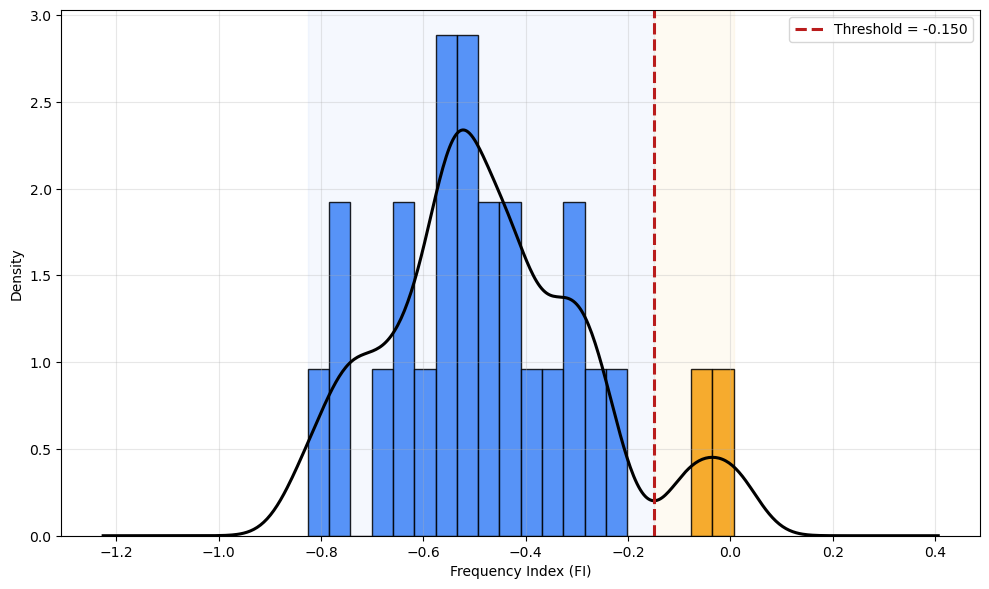

In [ ]:
# %% [markdown]
# ## 9. Histograma + KDE + mínimo local interno

# %%
if len(valid_df) > 0:
    fi_vals = valid_df["fi"].dropna().values

    LP_COLOR = "#3B82F6"
    VT_COLOR = "#F59E0B"
    THR_COLOR = "#B91C1C"
    CURVE_COLOR = "black"
    MIN_COLOR = "#7C3AED"
    SEL_MIN_COLOR = "#DC2626"

    fig, ax = plt.subplots(figsize=(10, 6))

    counts, bins, patches = ax.hist(
        fi_vals,
        bins=PLOT["hist_bins"],
        density=True,
        edgecolor="black",
        linewidth=1.0,
        alpha=0.85
    )

    if threshold is not None:
        for left, right, patch in zip(bins[:-1], bins[1:], patches):
            center = 0.5 * (left + right)
            if center < threshold:
                patch.set_facecolor(LP_COLOR)
            else:
                patch.set_facecolor(VT_COLOR)

    x_grid = threshold_debug.get("x_grid", None) if threshold_debug is not None else None
    density = threshold_debug.get("density", None) if threshold_debug is not None else None
    minima = threshold_debug.get("minima", None) if threshold_debug is not None else None
    internal_minima = threshold_debug.get("internal_minima", None) if threshold_debug is not None else None
    selected_minimum = threshold_debug.get("selected_minimum", None) if threshold_debug is not None else None

    if x_grid is not None and density is not None:
        ax.plot(x_grid, density, color=CURVE_COLOR, linewidth=2.2)

    

    if threshold is not None:
        ax.axvline(
            threshold,
            color=THR_COLOR,
            linestyle="--",
            linewidth=2.2,
            label=f"Threshold = {threshold:.3f}"
        )
        ax.axvspan(bins[0], threshold, color=LP_COLOR, alpha=0.05, zorder=0)
        ax.axvspan(threshold, bins[-1], color=VT_COLOR, alpha=0.05, zorder=0)

    ax.set_xlabel("Frequency Index (FI)")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(PATHS["output_dir"] / "fi_histogram_density.png", dpi=150)
    plt.show()

else:
    print("No hay eventos válidos para graficar el histograma.")

In [20]:
# Crear tabla mínima: solo event_id + clase final
if len(valid_df) > 0:
    fi_class_df = (
        valid_df[["event_id", "fi_class"]]
        .drop_duplicates(subset=["event_id"])
        .copy()
    )
else:
    fi_class_df = pd.DataFrame(columns=["event_id", "fi_class"])

# Anexar SOLO la columna de clase al catálogo filtrado
output = catalog_filtered.copy().merge(
    fi_class_df,
    on="event_id",
    how="left"
)

# Crear columna final llamada FI
output["FI"] = output["fi_class"].fillna("NS")

# Dejar solo las columnas originales del catálogo filtrado + FI
original_cols = list(catalog_filtered.columns)
output = output[original_cols + ["FI"]]

# Guardar
output.to_csv(PATHS["output_csv"], index=False)

print(f"Resultados guardados en: {PATHS['output_csv']}")
print(f"Eventos guardados: {len(output)}")

print("\nResumen de clases:")
print(output["FI"].value_counts(dropna=False))

output.head()

Resultados guardados en: /home/elizabeth/soft/src/QuickQuake/data/merged/output/GAMMA_hypodd_catalog_qcfiltered_FI.csv
Eventos guardados: 37

Resumen de clases:
FI
LP    23
NS    12
VT     2
Name: count, dtype: int64


,time,latitude,longitude,depth_km,magnitude,event_id,pc_ratio_energy,r_km,inside_radius,FI
0,2021-07-29 23:38:45.560000+00:00,55.275187,-160.801123,38.87,2.26,102,5.33,71.097039,True,NS
1,2021-07-29 09:17:38.700000+00:00,55.305945,-160.990641,42.75,2.17,12,5.44,58.595550,True,NS
2,2021-07-29 09:23:24.100000+00:00,55.285429,-160.919629,39.37,2.00,13,5.22,63.508531,True,NS
3,2021-07-29 09:43:51.900000+00:00,55.092546,-161.474805,19.77,1.37,18,10.15,44.906842,True,NS
4,2021-07-29 09:52:54.660000+00:00,55.277881,-161.239323,21.15,2.17,20,8.64,44.320070,True,LP


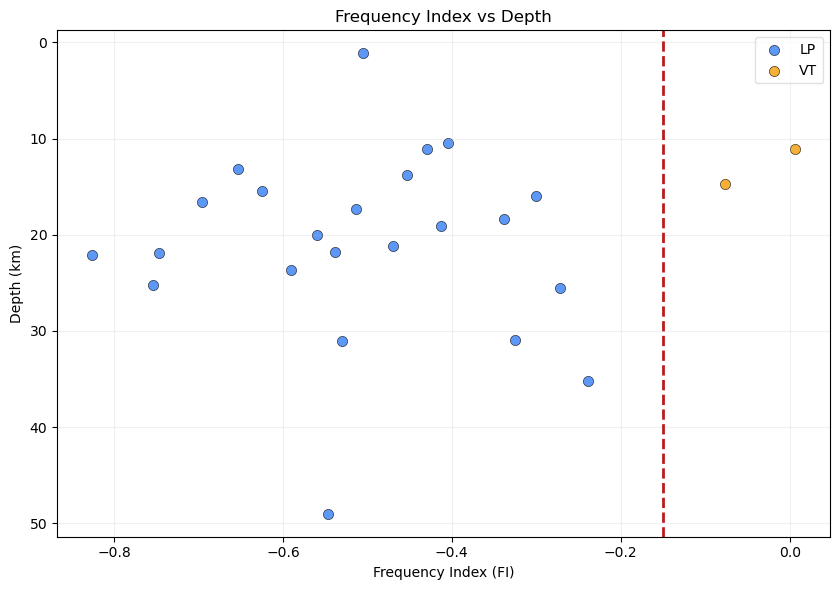

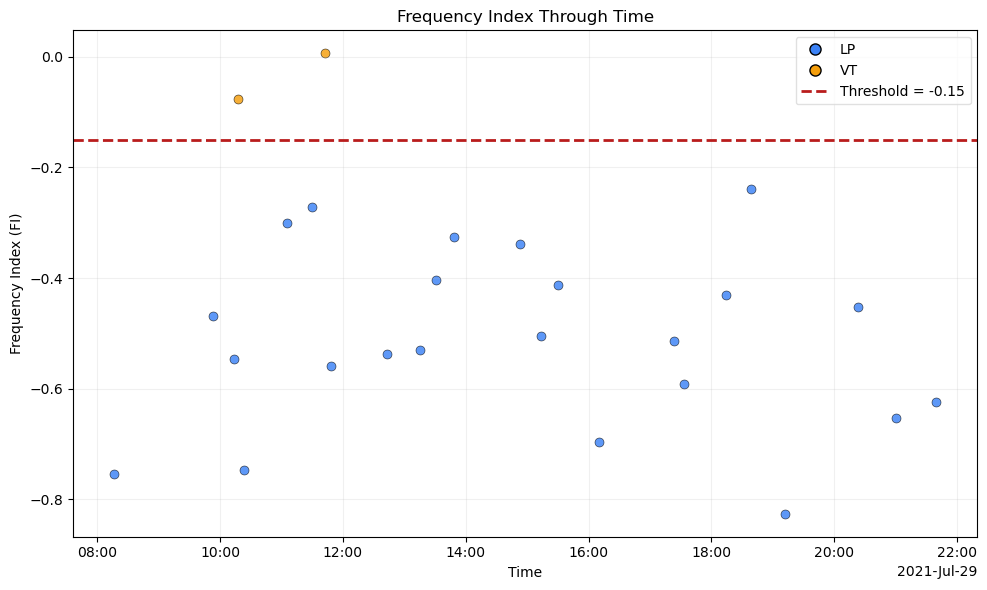

In [21]:
# %% [markdown]
# ## 11. Figuras FI vs Depth y FI vs Time

# %%
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

if len(valid_df) > 0:
    LP_COLOR = "#3B82F6"
    VT_COLOR = "#F59E0B"
    UNR_COLOR = "#6B7280"
    THR_COLOR = "#B91C1C"
    GRID_ALPHA = 0.18

    plot_df = valid_df.copy().sort_values("event_time").reset_index(drop=True)
    lp_df = plot_df[plot_df["fi_class"] == "LP"].copy()
    vt_df = plot_df[plot_df["fi_class"] == "VT"].copy()
    unr_df = plot_df[plot_df["fi_class"] == "UNRESOLVED"].copy()

    # ------------------------------------------------------------
    # FIGURA 1: FI VS DEPTH
    # ------------------------------------------------------------
    fig_depth, ax_depth = plt.subplots(figsize=(8.5, 6))

    if "event_depth_km" in plot_df.columns and plot_df["event_depth_km"].notna().any():
        if len(lp_df) > 0:
            ax_depth.scatter(
                lp_df["fi"], lp_df["event_depth_km"],
                s=54, c=LP_COLOR, edgecolors="black", linewidth=0.45,
                alpha=0.82, label="LP"
            )

        if len(vt_df) > 0:
            ax_depth.scatter(
                vt_df["fi"], vt_df["event_depth_km"],
                s=54, c=VT_COLOR, edgecolors="black", linewidth=0.45,
                alpha=0.82, label="VT"
            )

        if len(unr_df) > 0:
            ax_depth.scatter(
                unr_df["fi"], unr_df["event_depth_km"],
                s=54, c=UNR_COLOR, edgecolors="black", linewidth=0.45,
                alpha=0.82, label="UNRESOLVED"
            )

        if threshold is not None:
            ax_depth.axvline(threshold, color=THR_COLOR, linestyle="--", linewidth=2.0)

        ax_depth.set_xlabel("Frequency Index (FI)")
        ax_depth.set_ylabel("Depth (km)")
        ax_depth.set_title("Frequency Index vs Depth")
        ax_depth.grid(True, alpha=GRID_ALPHA)
        ax_depth.invert_yaxis()
        ax_depth.legend(frameon=True, facecolor="white", edgecolor="0.85")

        plt.tight_layout()
        fig_depth.savefig(PATHS["output_dir"] / "fi_vs_depth.png", bbox_inches="tight", dpi=150)
        fig_depth.savefig(PATHS["output_dir"] / "fi_vs_depth.pdf", bbox_inches="tight")
        plt.show()

    else:
        print("No hay columna de profundidad válida para FI vs Depth.")

    # ------------------------------------------------------------
    # FIGURA 2: FI VS TIME
    # ------------------------------------------------------------
    fig_time, ax_time = plt.subplots(figsize=(10, 6))

    if len(lp_df) > 0:
        ax_time.scatter(
            lp_df["event_time"], lp_df["fi"],
            s=42, c=LP_COLOR, edgecolors="black", linewidth=0.4,
            alpha=0.82, label="LP"
        )

    if len(vt_df) > 0:
        ax_time.scatter(
            vt_df["event_time"], vt_df["fi"],
            s=42, c=VT_COLOR, edgecolors="black", linewidth=0.4,
            alpha=0.82, label="VT"
        )

    if len(unr_df) > 0:
        ax_time.scatter(
            unr_df["event_time"], unr_df["fi"],
            s=42, c=UNR_COLOR, edgecolors="black", linewidth=0.4,
            alpha=0.82, label="UNRESOLVED"
        )

    if threshold is not None:
        ax_time.axhline(threshold, color=THR_COLOR, linestyle="--", linewidth=2.0)

    ax_time.set_xlabel("Time")
    ax_time.set_ylabel("Frequency Index (FI)")
    ax_time.set_title("Frequency Index Through Time")
    ax_time.grid(True, alpha=GRID_ALPHA)

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax_time.xaxis.set_major_locator(locator)
    ax_time.xaxis.set_major_formatter(formatter)

    legend_elements = []
    if len(lp_df) > 0:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=LP_COLOR,
                   markeredgecolor='black', markersize=8, label='LP')
        )
    if len(vt_df) > 0:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=VT_COLOR,
                   markeredgecolor='black', markersize=8, label='VT')
        )
    if len(unr_df) > 0:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=UNR_COLOR,
                   markeredgecolor='black', markersize=8, label='UNRESOLVED')
        )
    if threshold is not None:
        legend_elements.append(
            Line2D([0], [0], color=THR_COLOR, linestyle='--', linewidth=2,
                   label=f'Threshold = {threshold:.2f}')
        )

    if len(legend_elements) > 0:
        ax_time.legend(handles=legend_elements, frameon=True, facecolor="white", edgecolor="0.85")

    plt.tight_layout()
    fig_time.savefig(PATHS["output_dir"] / "fi_vs_time.png", bbox_inches="tight", dpi=150)
    fig_time.savefig(PATHS["output_dir"] / "fi_vs_time.pdf", bbox_inches="tight")
    plt.show()

else:
    print("No hay eventos válidos para graficar.")